In [ ]:
import pandas as pd

# Load dataset baru
file_path = "/content/weather_classification_data.csv"
df = pd.read_csv(file_path)
df = df[df['Weather Type'].isin(['Sunny', 'Cloudy', 'Rainy'])]

weather_mapping = {
    'Sunny': 'Cerah',
    'Cloudy': 'Berawan',
    'Rainy': 'Hujan'
}

df['Weather Type'] = df['Weather Type'].replace(weather_mapping)


# Tampilkan beberapa baris awal dan info kolom
df.head(), df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 9900 entries, 0 to 13199
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature           9900 non-null   float64
 1   Humidity              9900 non-null   int64  
 2   Wind Speed            9900 non-null   float64
 3   Precipitation (%)     9900 non-null   float64
 4   Cloud Cover           9900 non-null   object 
 5   Atmospheric Pressure  9900 non-null   float64
 6   UV Index              9900 non-null   int64  
 7   Season                9900 non-null   object 
 8   Visibility (km)       9900 non-null   float64
 9   Location              9900 non-null   object 
 10  Weather Type          9900 non-null   object 
dtypes: float64(5), int64(2), object(4)
memory usage: 928.1+ KB


(   Temperature  Humidity  Wind Speed  Precipitation (%)    Cloud Cover  \
 0         14.0        73         9.5               82.0  partly cloudy   
 1         39.0        96         8.5               71.0  partly cloudy   
 2         30.0        64         7.0               16.0          clear   
 3         38.0        83         1.5               82.0          clear   
 4         27.0        74        17.0               66.0       overcast   
 
    Atmospheric Pressure  UV Index  Season  Visibility (km)  Location  \
 0               1010.82         2  Winter              3.5    inland   
 1               1011.43         7  Spring             10.0    inland   
 2               1018.72         5  Spring              5.5  mountain   
 3               1026.25         7  Spring              1.0   coastal   
 4                990.67         1  Winter              2.5  mountain   
 
   Weather Type  
 0        Hujan  
 1      Berawan  
 2        Cerah  
 3        Cerah  
 4        Hujan  ,

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Encode fitur kategorikal
categorical_features = ['Cloud Cover', 'Season', 'Location']
df_encoded = df.copy()
le_dict = {}

for col in categorical_features:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    le_dict[col] = le

# Encode label
label_encoder = LabelEncoder()
df_encoded['Weather Type'] = label_encoder.fit_transform(df_encoded['Weather Type'])

# Pisahkan fitur dan label
X = df_encoded.drop(columns=['Weather Type'])
y = df_encoded['Weather Type']

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

X_train.shape, X_test.shape, y_train.shape, y_test.shape, len(label_encoder.classes_)


((7920, 10), (1980, 10), (7920,), (1980,), 3)

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# One-hot encoding untuk label
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

# Bangun model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(3, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Callback
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Training model
history = model.fit(X_train, y_train_cat, epochs=50, batch_size=32, validation_split=0.2, callbacks=[early_stopping])


Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


198/198 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6375 - loss: 0.8192 - val_accuracy: 0.8706 - val_loss: 0.4019
Epoch 2/50
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8596 - loss: 0.4344 - val_accuracy: 0.8845 - val_loss: 0.3270
Epoch 3/50
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8718 - loss: 0.3782 - val_accuracy: 0.8977 - val_loss: 0.2921
Epoch 4/50
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8797 - loss: 0.3477 - val_accuracy: 0.9040 - val_loss: 0.2699
Epoch 5/50
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8880 - loss: 0.3119 - val_accuracy: 0.9047 - val_loss: 0.2528
Epoch 6/50
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8953 - loss: 0.2792 - val_accuracy: 0.9085 - val_loss: 0.2457
Epoch 7/50
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8917 - loss: 0.2852 - val_accuracy: 0.9072 - val_loss: 0.2347
Epoch 8/50
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9022 - loss: 0.2609 - val_accuracy: 0.9072 - val_

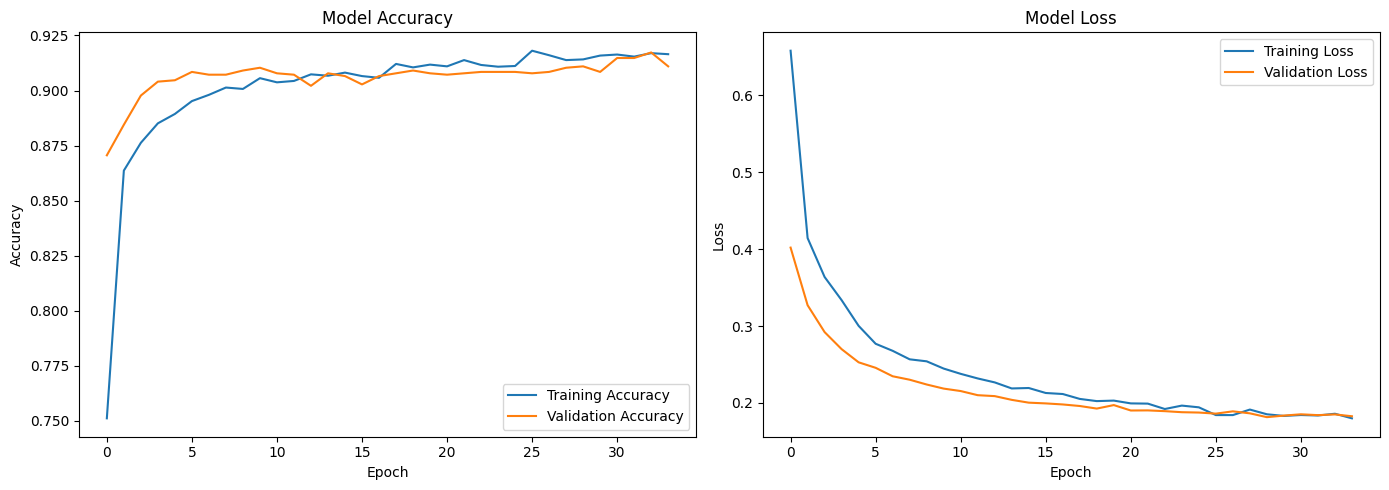

In [ ]:
# Plot akurasi dan loss
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


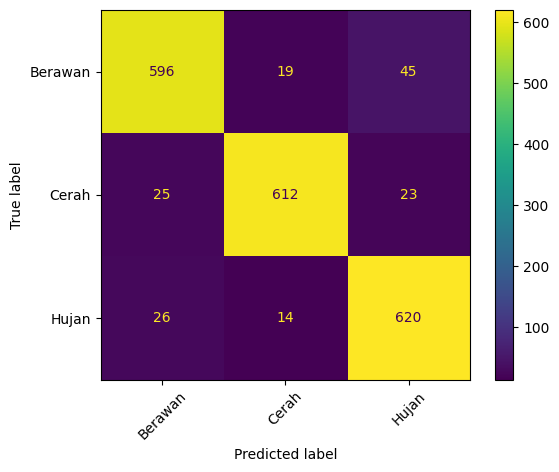

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
# Evaluation
y_pred = model.predict(X_test).argmax(axis=1)
y_test_labels = np.argmax(y_test_cat, axis=1)


# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(xticks_rotation=45)
plt.show()

      Metric     Score
0  Precision  0.923725
1     Recall  0.923232
2   F1-Score  0.923275


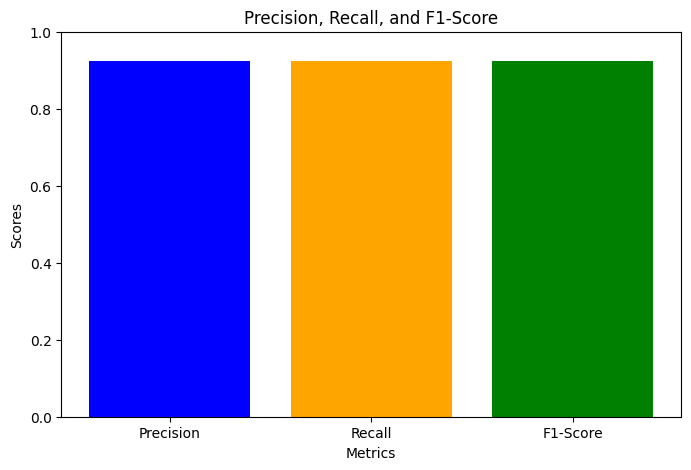

In [ ]:
from sklearn.metrics import precision_recall_fscore_support

# Hitung precision, recall, dan F1 score
precision, recall, f1, _ = precision_recall_fscore_support(y_test_labels, y_pred, average='weighted')

# Visualisasi metrik
metrics = {'Precision': precision, 'Recall': recall, 'F1-Score': f1}

metrics_df = pd.DataFrame({
    'Metric': ['Precision', 'Recall', 'F1-Score'],
    'Score': [precision, recall, f1]
})

# Tampilkan tabel
print(metrics_df)

# Plotting
plt.figure(figsize=(8, 5))
plt.bar(metrics.keys(), metrics.values(), color=['blue', 'orange', 'green'])
plt.xlabel('Metrics')
plt.ylabel('Scores')
plt.title('Precision, Recall, and F1-Score')
plt.ylim(0, 1)
plt.show()